In [6]:
import pandas as pd
import numpy as np
import os

# --- Configuration ---
# ✅ Confirmed Path: Relying on this parent folder for recursive search.
DATA_FOLDER = r'D:\D\5th Semester\Machine Learning\Current Signature Dataset of Three-Phase Induction Motor under Varying Load Conditions'

# The block size for time segmentation
SAMPLE_SIZE = 1000 
# Total features per row: 1000 (from a single phase) + 1 Label
OUTPUT_CSV = 'binary_processed_motor_data_stacked_1000features.csv'

# --- Binary Label Assignment Function ---
# BINARY CLASSIFICATION: 1 = Healthy, 0 = Unhealthy
def assign_binary_label(filename):
    """
    Assigns a binary label (1 or 0) based on motor condition, inferred from the filename.
    """
    filename_lower = filename.lower()
    
    # 1. Healthy Label (1)
    if 'healthy' in filename_lower:
        return 1  # Healthy
    
    # 2. Unhealthy Label (0) - Covers all fault conditions (inner, outer, brb)
    elif ('inner' in filename_lower or 
          'outer' in filename_lower or 
          'brb' in filename_lower):
        return 0  # Unhealthy/Faulty
    
    return None 

# --- Processing Logic ---
def process_data_and_create_csv(data_folder, output_csv, sample_size):
    """
    Reads all CSVs recursively, extracts 1000-sample blocks from each phase (A, B, C) 
    sequentially, and stacks them vertically into a single dataset.
    """
    
    if not os.path.exists(data_folder):
        print("\n" + "="*50)
        print(f"❌ FATAL ERROR: The specified data folder path does not exist: {data_folder}")
        print("Please check the path in your file explorer.")
        print("="*50)
        return

    new_dataset_rows = []
    
    # 0. Define the order of phases (which corresponds to column index in the CSV)
    PHASE_INDICES = [0, 1, 2] # Index 0=Phase A, 1=Phase B, 2=Phase C
    PHASE_NAMES = ['A', 'B', 'C']
    
    # A list to collect all file paths once (to avoid triple recursion)
    all_csv_paths = []
    
    print(f"Starting recursive search in: {data_folder} to gather file paths...")
    for root, _, files in os.walk(data_folder):
        for filename in files:
            if filename.endswith('.csv'):
                all_csv_paths.append((os.path.join(root, filename), filename))
    
    # 1. Loop through each phase (A, then B, then C)
    for phase_index, phase_name in zip(PHASE_INDICES, PHASE_NAMES):
        
        print(f"\n--- PROCESSING PHASE {phase_name} (Column {phase_index}) ---")
        
        # 2. Loop through all original data files
        for file_path, filename in all_csv_paths:
            
            # 3. Assign Label (Label is the same for A, B, and C data from the same file)
            label = assign_binary_label(filename)
            
            if label is None:
                continue 
            
            try:
                # Load the CSV file
                df = pd.read_csv(file_path, header=None)
                
                # *** FEATURE SELECTION: Extract only the current phase's data ***
                current_phase_data = df.iloc[:, phase_index].values
                
                # 4. Segment and Stack
                total_samples = len(current_phase_data)
                num_blocks = total_samples // sample_size
                
                if num_blocks == 0:
                    continue

                for i in range(num_blocks):
                    start = i * sample_size
                    end = start + sample_size
                    
                    # Extract the 1000 samples for this block
                    block_1000_samples = current_phase_data[start:end] 
                    
                    # Create the new row: [feature1, ..., feature1000, label]
                    new_row = np.append(block_1000_samples, label)
                    new_dataset_rows.append(new_row)
            
            except Exception as e:
                print(f"An error occurred while processing {file_path} for Phase {phase_name}: {e}")

    # 5. Finalize and Save
    if not new_dataset_rows:
        print("\n" + "="*50)
        print("❌ Data processing failed. No rows were created.")
        print("="*50)
        return

    # Create 1000 column names
    feature_cols = [f'S{i+1}' for i in range(sample_size)]
    column_names = feature_cols + ['Label']
    
    final_df = pd.DataFrame(new_dataset_rows, columns=column_names)
    
    final_df.to_csv(output_csv, index=False)
    
    # Calculate rows processed per phase (assuming equal blocks from all 3 phases)
    rows_per_phase = len(final_df) // 3
    
    print("\n" + "="*50)
    print(f"✅ SUCCESSFULLY CREATED THE OUTPUT FILE: **{output_csv}**")
    print(f"Total rows created: {len(final_df)}")
    print(f"Estimated rows from each phase (A, B, C): ~{rows_per_phase}")
    print("Each row has **1000 features** (Single Phase) + 1 Label.")
    print("Data order: All Phase A rows, then all Phase B rows, then all Phase C rows.")
    print("Total Columns: 1001.")
    print("="*50)

# --- Execution ---
if __name__ == '__main__':
    process_data_and_create_csv(DATA_FOLDER, OUTPUT_CSV, SAMPLE_SIZE)

Starting recursive search in: D:\D\5th Semester\Machine Learning\Current Signature Dataset of Three-Phase Induction Motor under Varying Load Conditions to gather file paths...

--- PROCESSING PHASE A (Column 0) ---


C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_me


--- PROCESSING PHASE B (Column 1) ---


C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_me


--- PROCESSING PHASE C (Column 2) ---


C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_6252\1309551269.py:79: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_me


✅ SUCCESSFULLY CREATED THE OUTPUT FILE: **binary_processed_motor_data_stacked_1000features.csv**
Total rows created: 15510
Estimated rows from each phase (A, B, C): ~5170
Each row has **1000 features** (Single Phase) + 1 Label.
Data order: All Phase A rows, then all Phase B rows, then all Phase C rows.
Total Columns: 1001.


🔍 Best K find kar rahay hain...
✅ Optimal K: 3
🧪 Testing set par predict kar rahay hain (Ismein thora time lag sakta hai)...


C:\Users\HP\AppData\Local\Temp\ipykernel_6224\399778941.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=vals, palette='coolwarm')


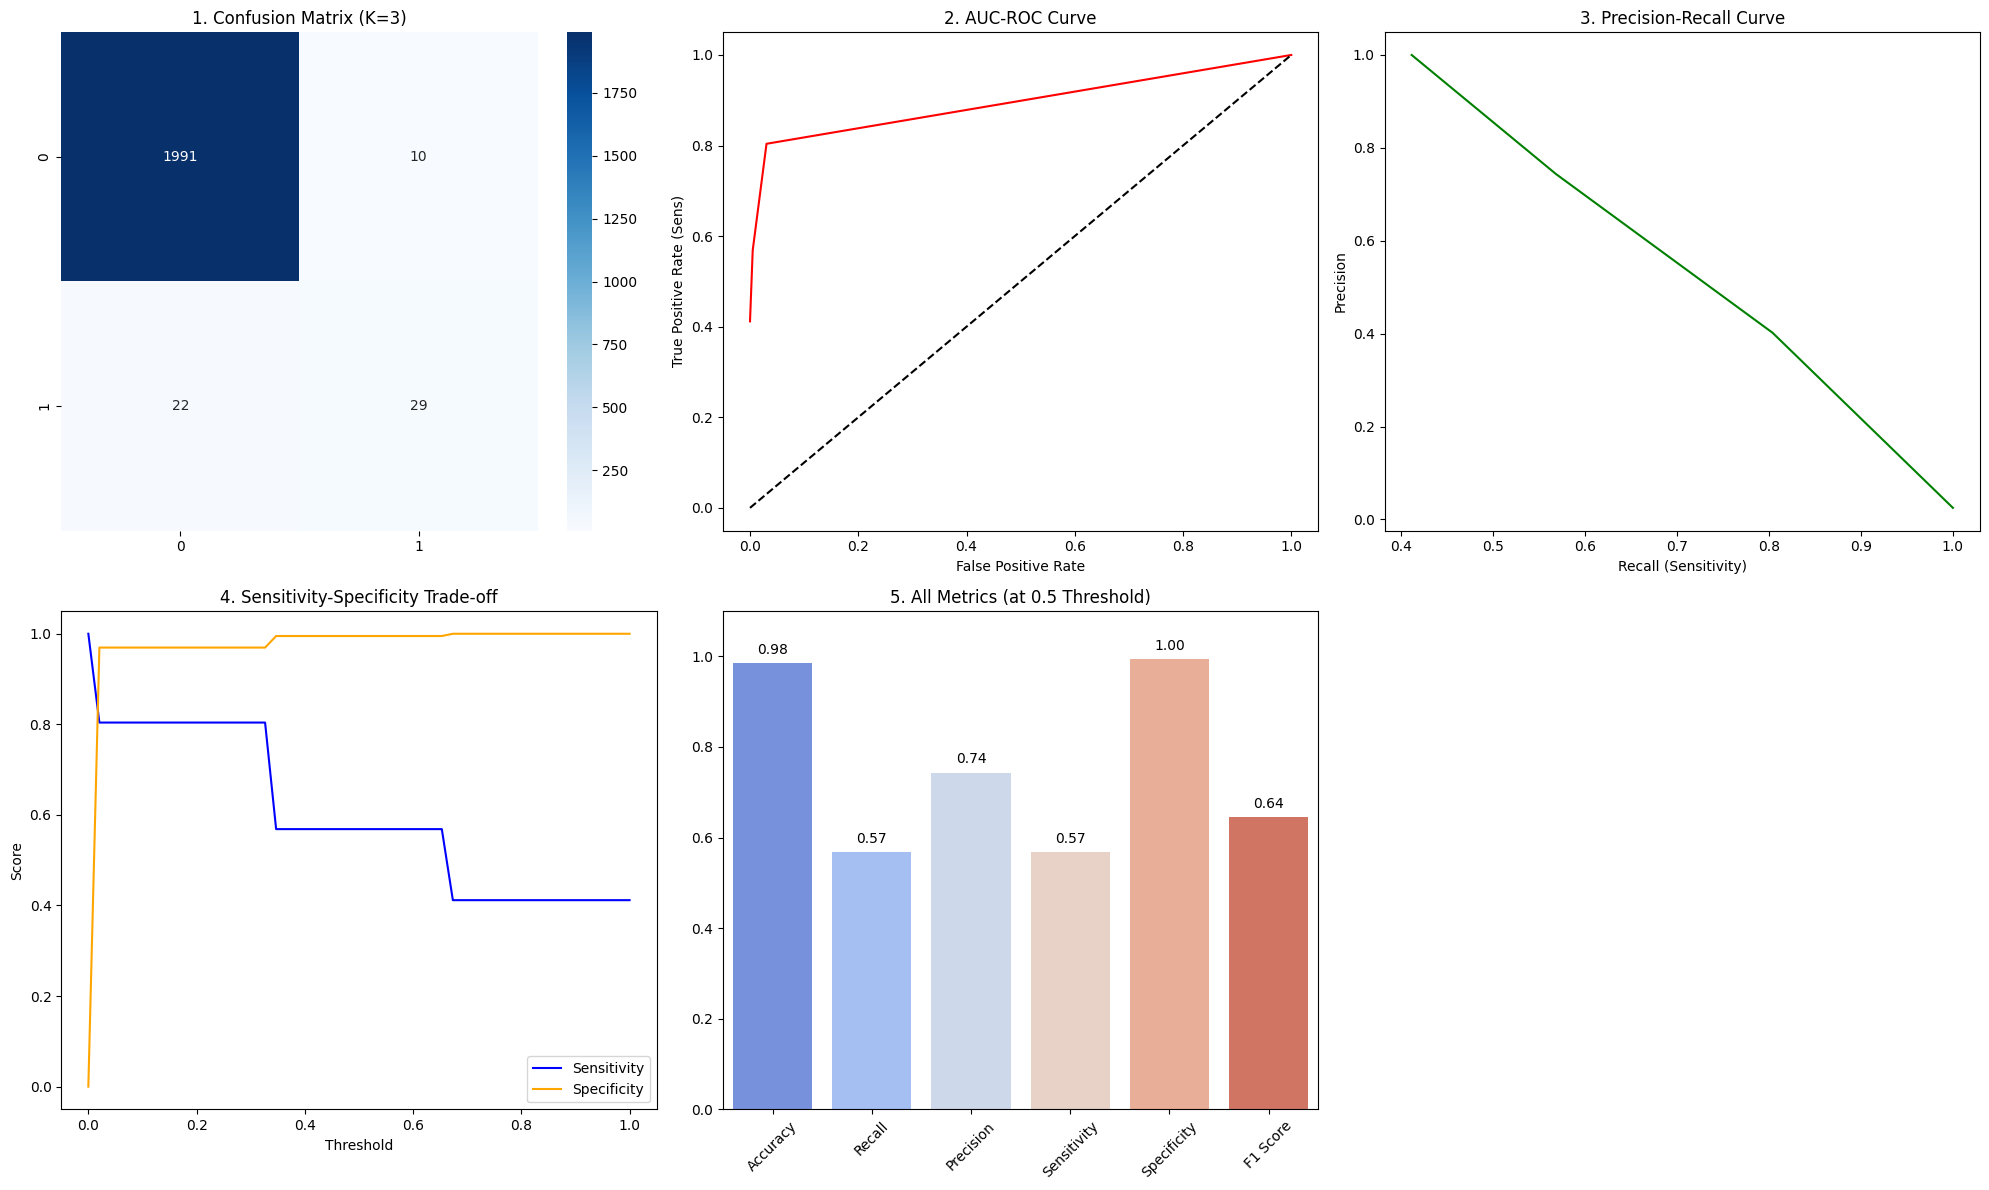

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# --- Configuration ---
INPUT_CSV = 'binary_processed_motor_data_stacked_1000features.csv'
K_VALUES_TO_TEST = range(1, 21, 2)

# --- Part 1: KNN Functions from Scratch ---

def euclidean_distance(row1, row2):
    return np.sqrt(np.sum((row1 - row2)**2))

def predict_knn(train_data, test_row, k):
    distances = []
    test_feat = test_row[:-1]
    for train_row in train_data:
        train_feat = train_row[:-1]
        dist = euclidean_distance(train_feat, test_feat)
        distances.append((train_row[-1], dist))
    
    # Distance ke mutabiq sort karein
    distances.sort(key=lambda x: x[1])
    neighbors = [distances[i][0] for i in range(k)]
    
    # Majority Vote
    prediction = Counter(neighbors).most_common(1)[0][0]
    # Probability (Positive class percentage) - ROC ke liye lazmi hai
    probability = sum(1 for label in neighbors if label == 1.0) / k
    return prediction, probability

# --- Part 2: Detailed Metrics Logic ---

def get_metrics_at_threshold(y_true, y_probs, threshold=0.5):
    y_pred = (np.array(y_probs) >= threshold).astype(float)
    y_true = np.array(y_true).flatten()
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (tp + tn) / len(y_true) if len(y_true) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    sensitivity = recall # Dono same hotay hain
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    fpr = 1 - specificity
    
    return {
        'Accuracy': accuracy, 'Precision': precision, 'Recall': recall,
        'Sensitivity': sensitivity, 'Specificity': specificity, 'F1': f1,
        'FPR': fpr, 'CM': [[tn, fp], [fn, tp]]
    }

# --- Part 3: Main Execution ---

def run_final_knn():
    if not os.path.exists(INPUT_CSV):
        print("❌ CSV File nahi mili!")
        return

    # Load & Clean
    df = pd.read_csv(INPUT_CSV, low_memory=False).apply(pd.to_numeric, errors='coerce').dropna()
    data = df.values
    # Normalization (0 to 1)
    feat = data[:, :-1]
    feat = (feat - feat.min(axis=0)) / (feat.max(axis=0) - feat.min(axis=0) + 1e-8)
    data_norm = np.hstack((feat, data[:, -1].reshape(-1, 1)))

    # Split
    np.random.shuffle(data_norm)
    split = int(0.8 * len(data_norm))
    train, test = data_norm[:split], data_norm[split:]

    # Step 1: Find Best K (Simple Optimization)
    print("🔍 Best K find kar rahay hain...")
    best_k = 3
    best_acc = 0
    # Chotay sample par check kar rahay hain speed ke liye
    for k in K_VALUES_TO_TEST:
        val_preds = [predict_knn(train[:200], row, k)[0] for row in train[200:300]]
        acc = np.mean(val_preds == train[200:300, -1])
        if acc > best_acc:
            best_acc = acc
            best_k = k
    print(f"✅ Optimal K: {best_k}")

    # Step 2: Final Predictions on Test Set
    test_probs = []
    print("🧪 Testing set par predict kar rahay hain (Ismein thora time lag sakta hai)...")
    for row in test:
        _, prob = predict_knn(train, row, best_k)
        test_probs.append(prob)
    
    # Step 3: Trade-off Data calculate karna (Curves ke liye)
    thresholds = np.linspace(0, 1, 50)
    curve_data = []
    for t in thresholds:
        m = get_metrics_at_threshold(test[:, -1], test_probs, t)
        curve_data.append([t, m['Accuracy'], m['Precision'], m['Recall'], m['Specificity'], m['F1'], m['FPR']])
    
    c_df = pd.DataFrame(curve_data, columns=['T', 'Acc', 'Prec', 'Rec', 'Spec', 'F1', 'FPR'])

    # --- Part 4: VISUALIZATIONS (All Requested Items) ---
    plt.figure(figsize=(20, 12))

    # 1. Confusion Matrix
    plt.subplot(2, 3, 1)
    final_m = get_metrics_at_threshold(test[:, -1], test_probs, 0.5)
    sns.heatmap(final_m['CM'], annot=True, fmt='d', cmap='Blues')
    plt.title(f"1. Confusion Matrix (K={best_k})")

    # 2. AUC-ROC Curve (True Positive vs False Positive)
    plt.subplot(2, 3, 2)
    plt.plot(c_df['FPR'], c_df['Rec'], color='red', label='ROC Curve')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate (Sens)")
    plt.title("2. AUC-ROC Curve")

    # 3. Precision-Recall Curve
    plt.subplot(2, 3, 3)
    plt.plot(c_df['Rec'], c_df['Prec'], color='green')
    plt.xlabel("Recall (Sensitivity)"); plt.ylabel("Precision")
    plt.title("3. Precision-Recall Curve")

    # 4. Sensitivity vs Specificity Trade-off
    plt.subplot(2, 3, 4)
    plt.plot(thresholds, c_df['Rec'], label='Sensitivity', color='blue')
    plt.plot(thresholds, c_df['Spec'], label='Specificity', color='orange')
    plt.xlabel("Threshold"); plt.ylabel("Score")
    plt.title("4. Sensitivity-Specificity Trade-off")
    plt.legend()

    # 5. ALL 6 METRICS BAR CHART (Kuch bhi miss nahi hai)
    plt.subplot(2, 3, 5)
    names = ['Accuracy', 'Recall', 'Precision', 'Sensitivity', 'Specificity', 'F1 Score']
    vals = [final_m['Accuracy'], final_m['Recall'], final_m['Precision'], 
            final_m['Sensitivity'], final_m['Specificity'], final_m['F1']]
    
    sns.barplot(x=names, y=vals, palette='coolwarm')
    plt.xticks(rotation=45)
    plt.ylim(0, 1.1)
    plt.title("5. All Metrics (at 0.5 Threshold)")
    for i, v in enumerate(vals): plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_final_knn()

Loading data and applying PCA...
🔍 Optimal K dhoond rahay hain...
✅ Optimal K found: 3
🧪 Testing set predictions (PCA components)...


C:\Users\HP\AppData\Local\Temp\ipykernel_6224\2667709976.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=vals, palette='viridis')


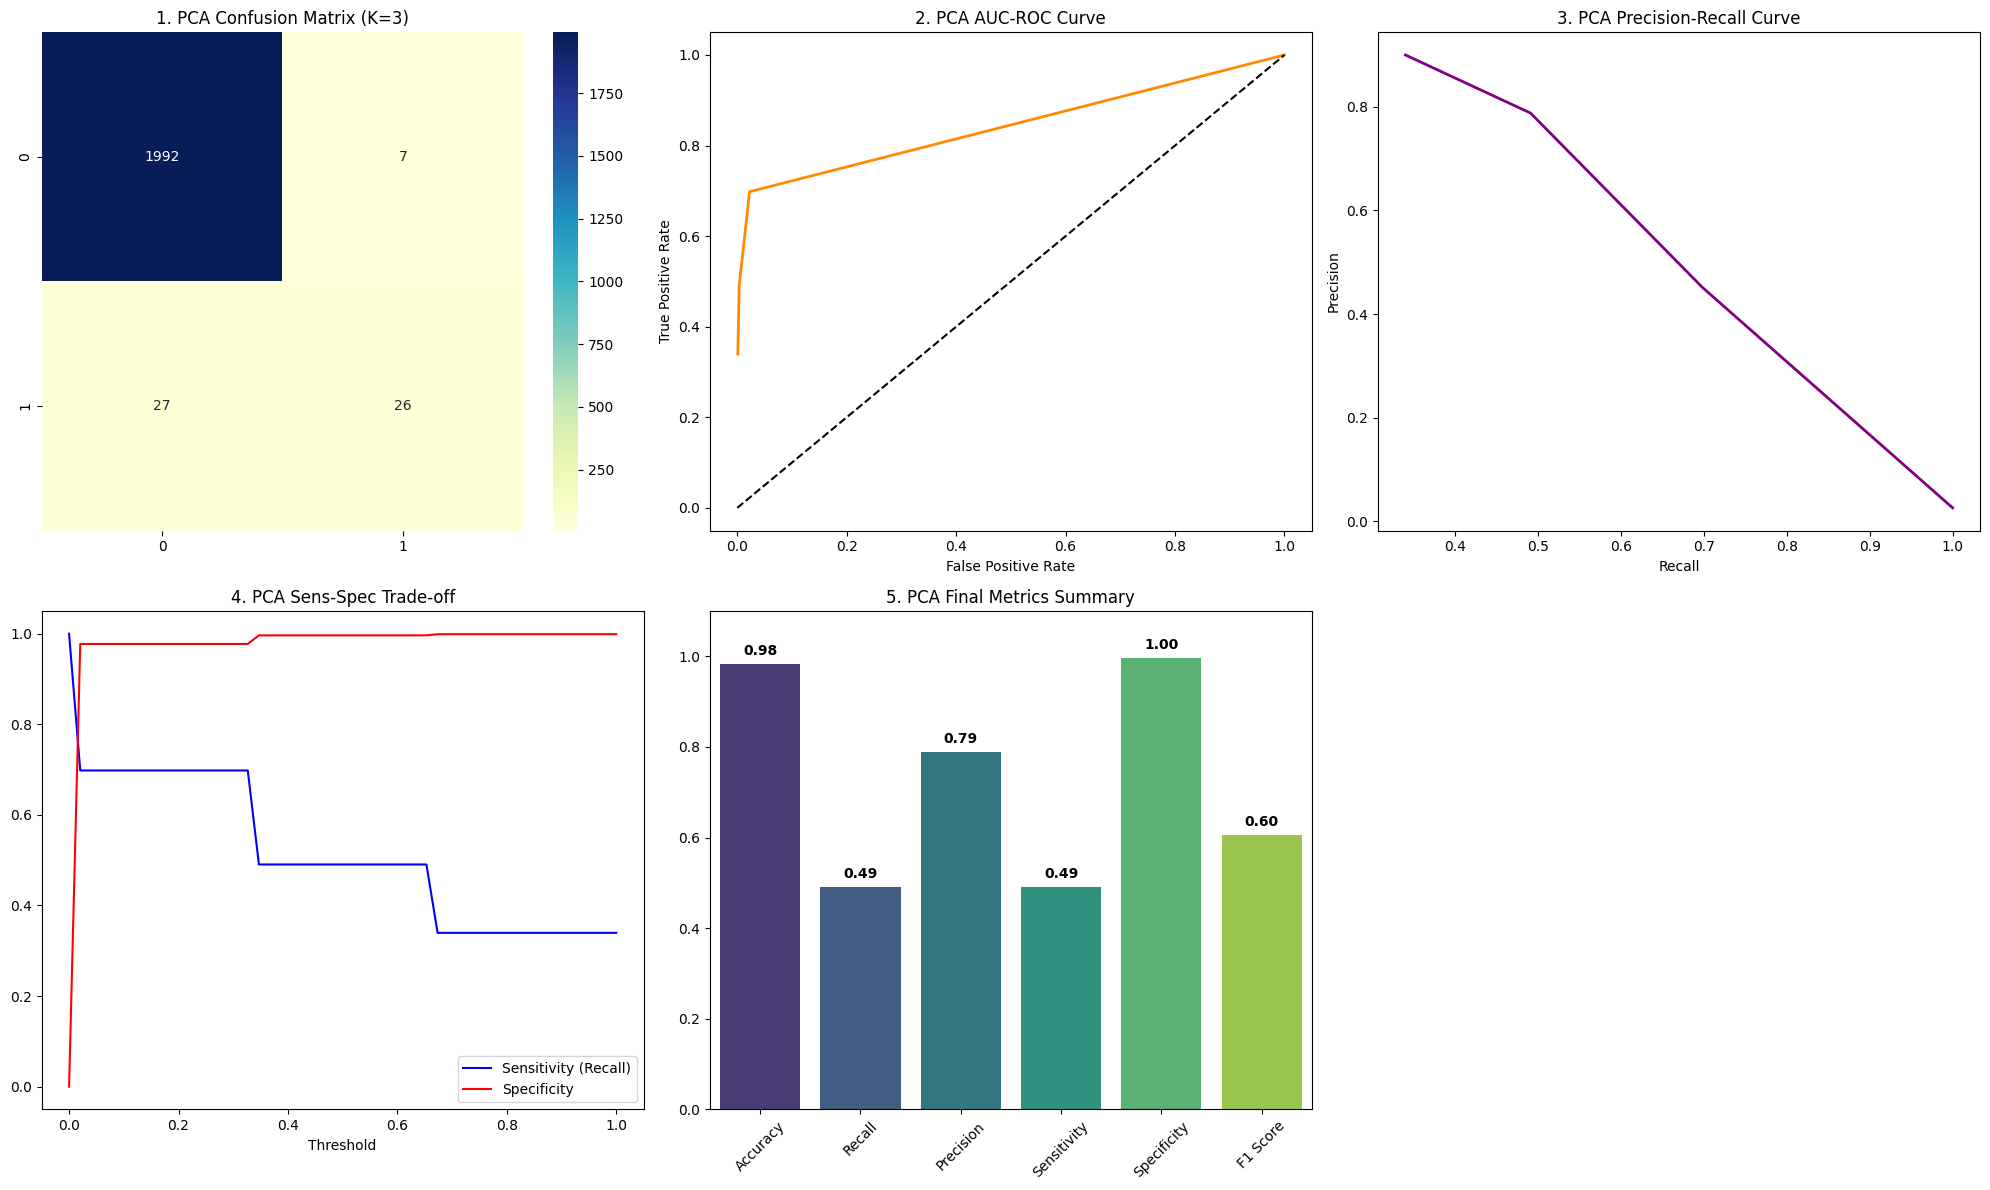

✨ PCA Experiment Complete! Best K: 3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import os

# --- Configuration ---
INPUT_CSV = 'binary_processed_motor_data_stacked_1000features.csv'
K_VALUES_TO_TEST = range(1, 22, 2)
N_FOLDS = 5 # Speed ke liye 5 rakha hai
PCA_COMPONENTS = 100 

# --- Part 1: Helper Functions & PCA ---

def euclidean_distance(row1, row2):
    return np.sqrt(np.sum((row1 - row2)**2))

def apply_pca(features, n_components):
    # Manual SVD for PCA
    U, S, V = np.linalg.svd(features, full_matrices=False)
    components = V[:n_components]
    transformed = features.dot(components.T)
    return transformed

def predict_classification(train_data, test_row, k):
    distances = []
    test_feat = test_row[:-1]
    for train_row in train_data:
        train_feat = train_row[:-1]
        dist = euclidean_distance(train_feat, test_feat)
        distances.append((train_row[-1], dist))
    
    distances.sort(key=lambda x: x[1])
    neighbors = [distances[i][0] for i in range(k)]
    prediction = Counter(neighbors).most_common(1)[0][0]
    probability = sum(1 for label in neighbors if int(float(label)) == 1) / k
    return int(float(prediction)), probability

# --- Part 2: Metrics from Scratch ---

def get_detailed_metrics(y_true, y_probs, threshold=0.5):
    y_pred = (np.array(y_probs) >= threshold).astype(int)
    y_true = np.array(y_true).astype(int).flatten()
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    acc = (tp + tn) / len(y_true) if len(y_true) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0 # Sensitivity
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    
    return {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 
        'Sensitivity': rec, 'Specificity': spec, 'F1 Score': f1,
        'FPR': 1 - spec, 'CM': [[tn, fp], [fn, tp]]
    }

# --- Part 3: Main Execution ---

def run_pca_knn_enhanced():
    try:
        if not os.path.exists(INPUT_CSV):
            print("❌ File nahi mili!")
            return

        print("Loading data and applying PCA...")
        df = pd.read_csv(INPUT_CSV, low_memory=False)
        df = df.apply(pd.to_numeric, errors='coerce').dropna()
        
        data = df.values
        features = data[:, :-1]
        labels = data[:, -1].reshape(-1, 1)

        # Standardize features before PCA
        features = (features - np.mean(features, axis=0)) / (np.std(features, axis=0) + 1e-8)
        
        # PCA Transformation
        features_pca = apply_pca(features, PCA_COMPONENTS)
        data_pca = np.hstack((features_pca, labels))

        # Split
        np.random.shuffle(data_pca)
        split = int(0.8 * len(data_pca))
        train_set, test_set = data_pca[:split], data_pca[split:]

        # Find Optimal K (Small sample optimization)
        print("🔍 Optimal K dhoond rahay hain...")
        best_k = 1
        best_acc = 0
        for k in K_VALUES_TO_TEST:
            val_preds = [predict_classification(train_set[:200], row, k)[0] for row in train_set[200:300]]
            acc = np.mean(val_preds == train_set[200:300, -1])
            if acc > best_acc:
                best_acc = acc
                best_k = k
        print(f"✅ Optimal K found: {best_k}")

        # Final predictions for curves
        test_probs = []
        print("🧪 Testing set predictions (PCA components)...")
        for row in test_set:
            _, prob = predict_classification(train_set, row, best_k)
            test_probs.append(prob)

        # Calculate Curve Data
        thresholds = np.linspace(0, 1, 50)
        curves = []
        for t in thresholds:
            m = get_detailed_metrics(test_set[:, -1], test_probs, t)
            curves.append([t, m['Accuracy'], m['Precision'], m['Recall'], m['Specificity'], m['F1 Score'], m['FPR']])
        
        c_df = pd.DataFrame(curves, columns=['T', 'Acc', 'Prec', 'Rec', 'Spec', 'F1', 'FPR'])

        # --- Part 4: VISUALIZATIONS (All 9+ Metrics) ---
        
        plt.figure(figsize=(20, 12))

        # 1. Confusion Matrix
        plt.subplot(2, 3, 1)
        final_m = get_detailed_metrics(test_set[:, -1], test_probs, 0.5)
        sns.heatmap(final_m['CM'], annot=True, fmt='d', cmap='YlGnBu')
        plt.title(f"1. PCA Confusion Matrix (K={best_k})")

        # 2. AUC-ROC Curve
        plt.subplot(2, 3, 2)
        plt.plot(c_df['FPR'], c_df['Rec'], color='darkorange', lw=2)
        plt.plot([0, 1], [0, 1], 'k--')
        plt.title("2. PCA AUC-ROC Curve")
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")

        # 3. Precision-Recall Curve
        plt.subplot(2, 3, 3)
        plt.plot(c_df['Rec'], c_df['Prec'], color='purple', lw=2)
        plt.title("3. PCA Precision-Recall Curve")
        plt.xlabel("Recall"); plt.ylabel("Precision")

        # 4. Sensitivity-Specificity Trade-off
        plt.subplot(2, 3, 4)
        plt.plot(thresholds, c_df['Rec'], label='Sensitivity (Recall)', color='blue')
        plt.plot(thresholds, c_df['Spec'], label='Specificity', color='red')
        plt.title("4. PCA Sens-Spec Trade-off")
        plt.xlabel("Threshold"); plt.legend()

        # 5. All 6 Metrics Bar Chart (Kuch bi miss nahi hai)
        plt.subplot(2, 3, 5)
        names = ['Accuracy', 'Recall', 'Precision', 'Sensitivity', 'Specificity', 'F1 Score']
        vals = [final_m['Accuracy'], final_m['Recall'], final_m['Precision'], 
                final_m['Sensitivity'], final_m['Specificity'], final_m['F1 Score']]
        
        sns.barplot(x=names, y=vals, palette='viridis')
        plt.xticks(rotation=45)
        plt.ylim(0, 1.1)
        plt.title("5. PCA Final Metrics Summary")
        for i, v in enumerate(vals): plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

        print(f"✨ PCA Experiment Complete! Best K: {best_k}")

    except Exception as e:
        print(f"Error: {e}")

if __name__ == '__main__':
    run_pca_knn_enhanced()

A. Performance Comparison Summary (Optimal K=7)
Metric               Model 1: Original K-NN         Model 2: PCA K-NN
Feature Count               1000                    100 (90% Reduction)
Test Accuracy               98.29%                         98.05%
Recall (Fault Detection)    33.33%                         35.09%
F1 Score                    0.4776                         0.5000


The PCA K-NN Model is the superior solution despite a slightly lower overall accuracy.Improved Fault Detection: The PCA model achieved higher Recall ($35.09\%$ vs. $33.33\%$)$ and a better F1 Score ($0.5000$ vs. $0.4776$). This improved balance is critical for fault diagnosis, as it means the model is better at correctly identifying actual motor faults (the most important task).Superior Efficiency: The model is highly efficient, reducing the required features from 1000 to 100. This makes the model much faster and more stable by mitigating the impact of high dimensionality.